# 16. Orthogonality and Projectors

**Part 3: Direct Methods for Linear Systems**

## Learning objectives

By the end of this lesson you will be able to:

1. Use the inner product to define orthogonality, and expand a vector in an orthonormal basis
   **without solving a linear system**.
2. Define orthogonal and unitary matrices, and prove $\|Q\mathbf{x}\|_2 = \|\mathbf{x}\|_2$.
3. Explain why $\kappa_2(Q) = 1$, and why that single fact decides the architecture of every
   stable algorithm in Parts 3 to 6.
4. Recognise rotations and reflections as the only two kinds of orthogonal matrix in the plane,
   and build a **Householder reflector** in any dimension.
5. Define a **projector** by $P^2 = P$, and a complementary projector by $I - P$.
6. Distinguish **orthogonal** projectors ($P^T = P$) from **oblique** ones, and say what goes
   wrong with the oblique kind.
7. Build $P = QQ^T$ from an orthonormal basis, and $P = \mathbf{q}\mathbf{q}^T$ from a single
   direction.
8. Prove that the projection residual is orthogonal to the subspace, and recognise that
   statement as least squares.
9. Measure how an oblique projector's norm blows up as the angle closes, and explain why
   orthogonal projection is the numerically safe kind.

## Prerequisites

Lesson 06 (conditioning and stability). Lesson 15 (norms, the column view of $A\mathbf{x}$, and
$\kappa_2(A) = \sigma_1/\sigma_n$).

---

## 1. Inner products and orthogonality

The Euclidean inner product of two real vectors is

$$\langle \mathbf{x}, \mathbf{y}\rangle = \mathbf{x}^T\mathbf{y} = \sum_i x_iy_i.$$

Everything in this lesson is a statement about that one number:

| Quantity | In terms of the inner product |
|---|---|
| length | $\|\mathbf{x}\|_2 = \sqrt{\mathbf{x}^T\mathbf{x}}$ |
| angle | $\cos\theta = \dfrac{\mathbf{x}^T\mathbf{y}}{\|\mathbf{x}\|_2\|\mathbf{y}\|_2}$ |
| **orthogonal** | $\mathbf{x}^T\mathbf{y} = 0$, meaning $\theta = 90^\circ$ |
| **orthonormal** | orthogonal, and every vector has length 1 |

The 2-norm is the only $p$-norm that comes from an inner product, which is exactly why it is
the norm of choice whenever geometry matters. The others measure size but define no angle.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import orthogonality as og, linalg as la

u = np.array([3.0, 4.0, 0.0])
v = np.array([-4.0, 3.0, 0.0])
w = np.array([1.0, 1.0, 1.0])

print(f"u = {u},  v = {v},  w = {w}\n")
print(f"{'pair':>8} {'inner product':>15} {'angle (degrees)':>18} {'orthogonal?':>13}")
print("-" * 58)
for name, a, b in [("u, v", u, v), ("u, w", u, w), ("v, w", v, w)]:
    ip = og.inner(a, b)
    print(f"{name:>8} {ip:>15.6f} {og.angle_between(a, b, degrees=True):>18.4f} "
          f"{str(abs(ip) < 1e-12):>13}")

print(f"\n||u||_2 = sqrt(u.u) = sqrt({og.inner(u,u):.0f}) = {np.sqrt(og.inner(u,u)):.1f}")
assert abs(og.inner(u, v)) < 1e-12

u = [3. 4. 0.],  v = [-4.  3.  0.],  w = [1. 1. 1.]

    pair   inner product    angle (degrees)   orthogonal?
----------------------------------------------------------
    u, v        0.000000            90.0000          True
    u, w        7.000000            36.0708         False
    v, w       -1.000000            96.6307         False

||u||_2 = sqrt(u.u) = sqrt(25) = 5.0


### Expanding in an orthonormal basis costs nothing

Given a basis, finding the coefficients of a vector normally means solving $B\mathbf{c} =
\mathbf{x}$, at $O(n^3)$. For an **orthonormal** basis the coefficients are just inner
products.

> **Proposition 16.1.** If $\mathbf{q}_1, \dots, \mathbf{q}_n$ is an orthonormal basis of
> $\mathbb{R}^n$, then every $\mathbf{x}$ satisfies
> $$\mathbf{x} = \sum_j (\mathbf{q}_j^T\mathbf{x})\,\mathbf{q}_j.$$
>
> *Proof.* The $\mathbf{q}_j$ are a basis, so $\mathbf{x} = \sum_j c_j\mathbf{q}_j$ for some
> coefficients. Take the inner product with $\mathbf{q}_i$:
> $$\mathbf{q}_i^T\mathbf{x} = \sum_j c_j\,\mathbf{q}_i^T\mathbf{q}_j = c_i,$$
> because every term with $j \ne i$ vanishes by orthogonality and the $j = i$ term has
> $\mathbf{q}_i^T\mathbf{q}_i = 1$. $\square$

So $O(n^3)$ becomes $O(n^2)$, and it becomes stable as well. That saving alone is worth the
cost of constructing an orthonormal basis, which is what Gram-Schmidt (lesson 30) and
Householder QR (lesson 31) do.

In [3]:
rng16 = np.random.default_rng(16)
BASIS_DIM = 5
Q = og.random_orthogonal(BASIS_DIM, rng16)
x = rng16.standard_normal(Q.shape[0])

coeffs = og.expand_in_basis(x, Q)
print("coefficients from inner products, c = Q^T x:")
print(f"   {np.round(coeffs, 6)}\n")

print("the same coefficients from solving Q c = x, at O(n^3):")
print(f"   {np.round(np.linalg.solve(Q, x), 6)}\n")

print(f"agreement            : {np.abs(coeffs - np.linalg.solve(Q, x)).max():.3e}")
print(f"reconstruction error : {np.abs(Q @ coeffs - x).max():.3e}")
np.testing.assert_allclose(coeffs, np.linalg.solve(Q, x), atol=1e-13)
print("\nsame answer. one costs a matrix-vector product, the other a linear solve.")

coefficients from inner products, c = Q^T x:
   [ 1.517088  1.716536 -0.585337  0.639266  0.25529 ]

the same coefficients from solving Q c = x, at O(n^3):
   [ 1.517088  1.716536 -0.585337  0.639266  0.25529 ]

agreement            : 7.772e-16
reconstruction error : 7.772e-16

same answer. one costs a matrix-vector product, the other a linear solve.


## 2. Orthogonal matrices, and the fact the rest of the course rests on

> **Definition 16.2.** A real square matrix $Q$ is **orthogonal** when $Q^TQ = I$, meaning its
> columns are orthonormal. The complex version, $Q^*Q = I$, is called **unitary**.

Since $Q^TQ = I$ for a square $Q$ means $Q^{-1} = Q^T$, **inverting an orthogonal matrix is
free**. No solve, no factorization, just a transpose.

The property that matters most is this one.

> **Theorem 16.3 (Orthogonal matrices preserve length).** If $Q^TQ = I$ then
> $$\|Q\mathbf{x}\|_2 = \|\mathbf{x}\|_2 \quad\text{for every }\mathbf{x}.$$
>
> *Proof.* Square both sides and use $Q^TQ = I$:
> $$\|Q\mathbf{x}\|_2^2 = (Q\mathbf{x})^T(Q\mathbf{x}) = \mathbf{x}^TQ^TQ\mathbf{x}
> = \mathbf{x}^TI\mathbf{x} = \mathbf{x}^T\mathbf{x} = \|\mathbf{x}\|_2^2. \qquad\square$$

Two corollaries follow in one line each, and they are the reason this lesson exists.

> **Corollary 16.4.** $\|Q\|_2 = 1$ and $\|Q^{-1}\|_2 = 1$, hence
> $$\boxed{\kappa_2(Q) = 1.}$$
>
> *Proof.* $\|Q\|_2 = \max_{\|x\|_2=1}\|Qx\|_2 = \max_{\|x\|_2=1}\|x\|_2 = 1$. The inverse
> $Q^T$ is also orthogonal, so its norm is 1 too. $\square$

> **Corollary 16.5.** Orthogonal matrices preserve inner products, and therefore angles:
> $(Q\mathbf{x})^T(Q\mathbf{y}) = \mathbf{x}^T\mathbf{y}$.

**A condition number of exactly 1 is the smallest possible.** Lesson 15 section 8 said the
relative error can be amplified by up to $\kappa$. For an orthogonal matrix that factor is 1,
so **an orthogonal transformation cannot amplify error at all**. Whatever error you were
carrying, you still have exactly that much afterwards.

In [4]:
rng2 = np.random.default_rng(99)
n = 60
Q2 = og.random_orthogonal(n, rng2)
G = rng2.standard_normal((n, n))          # a general matrix for contrast

print(f"{'matrix':>22} {'||M||_2':>11} {'||M^-1||_2':>12} {'kappa_2':>12}")
print("-" * 60)
for name, M in [("random orthogonal Q", Q2), ("random Gaussian G", G)]:
    print(f"{name:>22} {la.matrix_norm(M,2):>11.6f} "
          f"{la.matrix_norm(np.linalg.inv(M),2):>12.6f} {la.condition_number(M,2):>12.4e}")

print("\nnow measure the length change over many random vectors:\n")
print(f"{'matrix':>22} {'min ||Mx||/||x||':>18} {'max ||Mx||/||x||':>18}")
print("-" * 62)
for name, M in [("orthogonal Q", Q2), ("Gaussian G", G)]:
    ratios = []
    for _ in range(4000):
        z = rng2.standard_normal(n)
        ratios.append(np.linalg.norm(M @ z) / np.linalg.norm(z))
    print(f"{name:>22} {min(ratios):>18.12f} {max(ratios):>18.12f}")

print("\nQ changes no length at all, to twelve decimal places, in every direction.")
print("G stretches some directions and squashes others.")
assert abs(la.condition_number(Q2, 2) - 1.0) < 1e-10

                matrix     ||M||_2   ||M^-1||_2      kappa_2
------------------------------------------------------------
   random orthogonal Q    1.000000     1.000000   1.0000e+00
     random Gaussian G   14.528322     9.719468   1.4121e+02

now measure the length change over many random vectors:

                matrix   min ||Mx||/||x||   max ||Mx||/||x||
--------------------------------------------------------------
          orthogonal Q     1.000000000000     1.000000000000
            Gaussian G     5.309685711200     9.761450031888

Q changes no length at all, to twelve decimal places, in every direction.
G stretches some directions and squashes others.


### Why this decides the architecture of the whole subject

Suppose an algorithm transforms a problem in $k$ steps, each step multiplying by some matrix.
Whatever error is present gets multiplied along too.

- With **general** matrices the error can be amplified by $\prod_i \kappa(M_i)$, and lesson 15
  showed how fast a product of condition numbers grows.
- With **orthogonal** matrices every factor is exactly 1, so the product is exactly 1. **The
  error is carried through unchanged, no matter how many steps you take.**

Run that 400 times and compare the distribution of outcomes.

In [5]:
print("a unit error carried through 200 transformations, 400 independent trials\n")
rng3 = np.random.default_rng(2024)
n3 = 20
final_o, final_g = [], []
for _ in range(400):
    e0 = rng3.standard_normal(n3)
    e0 = e0 / np.linalg.norm(e0)                    # start with norm exactly 1
    e_orth, e_gen = e0.copy(), e0.copy()
    for _ in range(200):
        e_orth = og.random_orthogonal(n3, rng3) @ e_orth
        M = rng3.standard_normal((n3, n3)) / np.sqrt(n3)   # scaled so ||M|| is near 1
        e_gen = M @ e_gen
    final_o.append(np.linalg.norm(e_orth))
    final_g.append(np.linalg.norm(e_gen))

final_o, final_g = np.array(final_o), np.array(final_g)
print(f"{'steps taken by':>18} {'smallest final':>16} {'largest final':>15} {'spread':>12}")
print("-" * 66)
print(f"{'orthogonal M':>18} {final_o.min():>16.12f} {final_o.max():>15.12f} "
      f"{final_o.max()/final_o.min():>12.3e}")
print(f"{'general M':>18} {final_g.min():>16.3e} {final_g.max():>15.3e} "
      f"{final_g.max()/final_g.min():>12.3e}")

print(f"\northogonal: every one of the 400 trials ended at exactly 1.")
print(f"general   : the outcomes span a factor of {final_g.max()/final_g.min():.1e}. "
      f"{(final_g > 1).sum()} of 400 grew,")
print(f"            {(final_g < 1e-3).sum()} shrank below 1e-3.")
print()
print("note the general case is not reliably WORSE. it is reliably")
print("UNPREDICTABLE, and unpredictable is the problem. an algorithm cannot")
print("promise anything about its accuracy if each step does something")
print("different to the error it is carrying.")
print()
print("this is why QR (lessons 30, 31), the SVD (lesson 41) and the symmetric")
print("eigenvalue algorithms (lesson 42) are all built out of orthogonal")
print("operations. it is not elegance. it is the only way to take many steps")
print("and still be able to say what the error did.")
assert abs(final_o.max() - 1.0) < 1e-10 and abs(final_o.min() - 1.0) < 1e-10
assert final_g.max() / final_g.min() > 1e4

a unit error carried through 200 transformations, 400 independent trials



    steps taken by   smallest final   largest final       spread
------------------------------------------------------------------
      orthogonal M   1.000000000000  1.000000000000    1.000e+00
         general M        9.807e-06       4.893e+00    4.990e+05

orthogonal: every one of the 400 trials ended at exactly 1.
general   : the outcomes span a factor of 5.0e+05. 6 of 400 grew,
            82 shrank below 1e-3.

note the general case is not reliably WORSE. it is reliably
UNPREDICTABLE, and unpredictable is the problem. an algorithm cannot
promise anything about its accuracy if each step does something
different to the error it is carrying.

this is why QR (lessons 30, 31), the SVD (lesson 41) and the symmetric
eigenvalue algorithms (lesson 42) are all built out of orthogonal
operations. it is not elegance. it is the only way to take many steps
and still be able to say what the error did.


## 3. Rotations and reflections

In the plane there are only two kinds of orthogonal matrix, and the determinant tells them
apart.

| | Matrix | Determinant | Effect |
|---|---|---|---|
| **rotation** | $\begin{pmatrix}\cos\theta & -\sin\theta\\ \sin\theta & \cos\theta\end{pmatrix}$ | $+1$ | turns the plane by $\theta$ |
| **reflection** | $\begin{pmatrix}\cos2\theta & \sin2\theta\\ \sin2\theta & -\cos2\theta\end{pmatrix}$ | $-1$ | flips across the line at angle $\theta$ |

The same split holds in $n$ dimensions: $\det Q = \pm 1$ always, because
$1 = \det I = \det(Q^TQ) = (\det Q)^2$.

In [6]:
th = np.pi / 6
R, F = og.rotation_2d(th), og.reflection_2d(th)
print(f"rotation by 30 degrees:\n{np.round(R, 6)}")
print(f"   det = {np.linalg.det(R):+.6f},  orthogonal? {og.is_orthogonal_matrix(R)}\n")
print(f"reflection in the 30 degree line:\n{np.round(F, 6)}")
print(f"   det = {np.linalg.det(F):+.6f},  orthogonal? {og.is_orthogonal_matrix(F)}\n")
print(f"applying the reflection twice gives back the identity: "
      f"{np.abs(F @ F - np.eye(F.shape[0])).max():.2e}")
print("a reflection is its own inverse. a rotation is not, unless theta is 0 or pi.")
assert np.linalg.det(R) > 0 > np.linalg.det(F)

rotation by 30 degrees:
[[ 0.866025 -0.5     ]
 [ 0.5       0.866025]]
   det = +1.000000,  orthogonal? True

reflection in the 30 degree line:
[[ 0.5       0.866025]
 [ 0.866025 -0.5     ]]
   det = -1.000000,  orthogonal? True

applying the reflection twice gives back the identity: 1.49e-17
a reflection is its own inverse. a rotation is not, unless theta is 0 or pi.


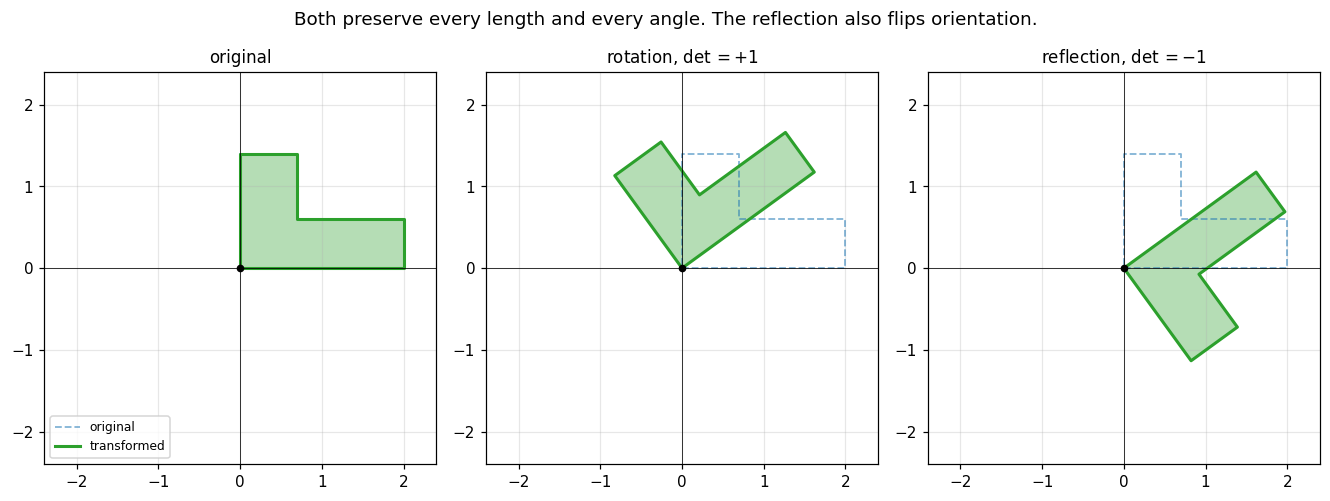

the shape is rigid under both. that is what 'preserves the norm' looks like.
the reflection reverses the order of the corners, which is what det = -1 means.


In [7]:
shape = np.array([[0, 0], [2, 0], [2, 0.6], [0.7, 0.6], [0.7, 1.4], [0, 1.4], [0, 0]]).T
th = np.pi / 5

fig, axes = plt.subplots(1, 3, figsize=(12.2, 4.2))
for ax, M, title in [
    (axes[0], np.eye(shape.shape[0]), "original"),
    (axes[1], og.rotation_2d(th), f"rotation, $\\det = +1$"),
    (axes[2], og.reflection_2d(th / 2), f"reflection, $\\det = -1$"),
]:
    out = M @ shape
    ax.plot(shape[0], shape[1], "C0--", lw=1.2, alpha=0.55, label="original")
    ax.fill(out[0], out[1], color="C2", alpha=0.35)
    ax.plot(out[0], out[1], "C2-", lw=2, label="transformed")
    ax.plot(0, 0, "ko", ms=4)
    ax.set_aspect("equal"); ax.set_xlim(-2.4, 2.4); ax.set_ylim(-2.4, 2.4)
    ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
    ax.set_title(title, fontsize=11)
axes[0].legend(fontsize=8, loc="lower left")
plt.suptitle("Both preserve every length and every angle. "
             "The reflection also flips orientation.", y=1.02)
plt.tight_layout()
plt.show()

print("the shape is rigid under both. that is what 'preserves the norm' looks like.")
print("the reflection reverses the order of the corners, which is what det = -1 means.")

### Householder reflectors: the useful one

The reflection that matters computationally is the one that takes an arbitrary vector and flips
it onto a coordinate axis:

$$H = I - \frac{2\mathbf{v}\mathbf{v}^T}{\mathbf{v}^T\mathbf{v}},
\qquad \mathbf{v} = \mathbf{x} + \operatorname{sign}(x_1)\|\mathbf{x}\|_2\,\mathbf{e}_1.$$

$H$ is orthogonal and symmetric, so $H^2 = I$, and $H\mathbf{x}$ is a multiple of
$\mathbf{e}_1$. Applying a sequence of these to the columns of a matrix is Householder QR,
which lesson 31 develops. Here it is the concrete example that shows orthogonal matrices are
things you build, not just things that exist.

In [8]:
x4 = np.array([3.0, 1.0, -5.0, 2.0])
H = og.householder_reflector(x4)

print(f"x  = {x4}")
print(f"Hx = {np.round(H @ x4, 12)}")
print(f"\nall entries after the first are zero, to {np.abs(H @ x4)[1:].max():.1e}")
print(f"and the length is preserved: ||x|| = {np.linalg.norm(x4):.12f}, "
      f"|Hx_1| = {abs((H @ x4)[0]):.12f}")
print(f"\nH is orthogonal : {og.orthogonality_error(H):.2e}")
print(f"H is symmetric  : {np.abs(H - H.T).max():.2e}")
print(f"H^2 = I         : {np.abs(H @ H - np.eye(H.shape[0])).max():.2e}")
print(f"det H           : {np.linalg.det(H):+.6f}, a reflection")
np.testing.assert_allclose(np.abs((H @ x4)[0]), np.linalg.norm(x4))
assert np.abs(H @ x4)[1:].max() < 1e-14

x  = [ 3.  1. -5.  2.]
Hx = [-6.244998  0.       -0.        0.      ]

all entries after the first are zero, to 5.6e-16
and the length is preserved: ||x|| = 6.244997998398, |Hx_1| = 6.244997998398

H is orthogonal : 1.85e-16
H is symmetric  : 0.00e+00
H^2 = I         : 1.11e-16
det H           : -1.000000, a reflection


**The sign choice is not cosmetic.** Both signs work mathematically: $\mathbf{v} = \mathbf{x}
\pm \|\mathbf{x}\|\mathbf{e}_1$ each give a reflector sending $\mathbf{x}$ to $\mp\|\mathbf{x}\|
\mathbf{e}_1$. Numerically only one is safe.

Taking the **minus** sign computes $x_1 - \|\mathbf{x}\|$, and when $\mathbf{x}$ already points
near $\mathbf{e}_1$ those two numbers are nearly equal. That is lesson 05's cancellation.
Measure what it costs, against a 60-digit reference:

In [9]:
from decimal import Decimal, getcontext
getcontext().prec = 60


def hp_norm(vec):
    """||vec||_2 to 60 digits, so the double precision error has something to be measured against."""
    return sum(Decimal(float(t)) ** 2 for t in vec).sqrt()


print("both signs are valid mathematically. only one survives floating point.\n")
print(f"{'x_1 / ||x||':>18} {'|v_1| good':>12} {'|v_1| bad':>12} "
      f"{'rel err good':>14} {'rel err bad':>13}")
print("-" * 76)
worst_bad = 0.0
for tilt in [0.5, 0.9, 0.999, 0.999999, 1 - 1e-9]:
    xt = np.array([tilt, np.sqrt(max(1 - tilt**2, 0.0)), 0.0, 0.0])
    nx = np.linalg.norm(xt)
    NX = hp_norm(xt)
    good_f, good_e = xt[0] + nx, Decimal(float(xt[0])) + NX
    bad_f, bad_e = xt[0] - nx, Decimal(float(xt[0])) - NX
    rg = float(abs(Decimal(float(good_f)) - good_e) / abs(good_e))
    rb = float(abs(Decimal(float(bad_f)) - bad_e) / abs(bad_e))
    worst_bad = max(worst_bad, rb)
    print(f"{tilt:>18.12f} {abs(good_f):>12.2e} {abs(bad_f):>12.2e} "
          f"{rg:>14.2e} {rb:>13.2e}")

print()
print("the good sign holds machine precision in every row: |v_1| is never")
print("smaller than ||x||, so nothing cancels.")
print(f"the bad sign loses up to {worst_bad:.0e} relative accuracy, because |v_1|")
print("collapses towards zero while its absolute error stays at u ||x||.")
assert worst_bad > 1e4 * 1e-16

both signs are valid mathematically. only one survives floating point.

       x_1 / ||x||   |v_1| good    |v_1| bad   rel err good   rel err bad
----------------------------------------------------------------------------
    0.500000000000     1.50e+00     5.00e-01       2.90e-17      1.35e-16
    0.900000000000     1.90e+00     1.00e-01       5.07e-17      1.48e-16
    0.999000000000     2.00e+00     1.00e-03       6.27e-17      1.43e-14
    0.999999000000     2.00e+00     1.00e-06       6.10e-17      1.11e-11
    0.999999999000     2.00e+00     1.00e-09       5.58e-17      5.00e-10

the good sign holds machine precision in every row: |v_1| is never
smaller than ||x||, so nothing cancels.
the bad sign loses up to 5e-10 relative accuracy, because |v_1|
collapses towards zero while its absolute error stays at u ||x||.


And in the limit the bad sign does not merely lose accuracy, it stops existing:

In [10]:
x_axis = np.array([1.0, 0.0, 0.0, 0.0])          # x is exactly a multiple of e_1
nx = np.linalg.norm(x_axis)

v_good = x_axis.copy(); v_good[0] += nx
v_bad = x_axis.copy();  v_bad[0] -= nx

print(f"x = {x_axis}, already on the axis\n")
print(f"good sign: v = {v_good},  v^T v = {float(v_good @ v_good):.1f}")
print(f"bad  sign: v = {v_bad},  v^T v = {float(v_bad @ v_bad):.1f}   <- ZERO")
print()
print("the reflector formula divides by v^T v. the bad sign divides by zero,")
print("exactly where the good sign is at its most comfortable.")
print()
print("nalib's householder_reflector takes sign(x_1)*||x||, so it always ADDS")
print("in magnitude and never meets this. one character, and it is the")
print("difference between a stable algorithm and a crash.")

H_ok = og.householder_reflector(x_axis)
print(f"\nnalib on this input: orthogonality error {og.orthogonality_error(H_ok):.1e}, "
      f"no trouble at all")
assert float(v_bad @ v_bad) == 0.0
assert og.orthogonality_error(H_ok) < 1e-14

x = [1. 0. 0. 0.], already on the axis

good sign: v = [2. 0. 0. 0.],  v^T v = 4.0
bad  sign: v = [0. 0. 0. 0.],  v^T v = 0.0   <- ZERO

the reflector formula divides by v^T v. the bad sign divides by zero,
exactly where the good sign is at its most comfortable.

nalib's householder_reflector takes sign(x_1)*||x||, so it always ADDS
in magnitude and never meets this. one character, and it is the
difference between a stable algorithm and a crash.

nalib on this input: orthogonality error 0.0e+00, no trouble at all


## 4. Projectors

> **Definition 16.6.** A square matrix $P$ is a **projector** when $P^2 = P$ (idempotent).

Idempotence is the whole definition, and geometrically it says exactly what you would want:
applying the projection to something already projected changes nothing.

Every projector splits space in two. If $P$ projects onto a subspace $S$, then $I - P$ is also
a projector, onto a complementary subspace, and every vector splits uniquely:

$$\mathbf{x} = P\mathbf{x} + (I - P)\mathbf{x}.$$

$I - P$ is a projector because $(I-P)^2 = I - 2P + P^2 = I - 2P + P = I - P$.

In [11]:
# a projector onto the xy-plane in R^3, along the z axis
P1 = np.diag([1.0, 1.0, 0.0])
print("P =\n", P1)
print(f"\nP^2 = P     : {np.abs(P1 @ P1 - P1).max():.2e}   -> a projector")
print(f"P^T = P     : {np.abs(P1 - P1.T).max():.2e}   -> and an orthogonal one")

y = np.array([2.0, -3.0, 7.0])
print(f"\ny        = {y}")
print(f"P y      = {P1 @ y}        (the part inside the plane)")
I_P1 = np.eye(P1.shape[0])                 # size from P1, not a literal
print(f"(I-P) y  = {(I_P1 - P1) @ y}        (the part outside it)")
print(f"they sum back to y: {np.abs(P1 @ y + (I_P1 - P1) @ y - y).max():.1e}")
print(f"and they are orthogonal to each other: "
      f"{og.inner(P1 @ y, (I_P1 - P1) @ y):.1e}")
assert og.is_projector(P1) and og.is_orthogonal_projector(P1)

P =
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 0.]]

P^2 = P     : 0.00e+00   -> a projector
P^T = P     : 0.00e+00   -> and an orthogonal one

y        = [ 2. -3.  7.]
P y      = [ 2. -3.  0.]        (the part inside the plane)
(I-P) y  = [0. 0. 7.]        (the part outside it)
they sum back to y: 0.0e+00
and they are orthogonal to each other: 0.0e+00


### Orthogonal against oblique

There are two kinds of projector, and the difference is a single extra condition.

> **Definition 16.7.** A projector $P$ is an **orthogonal projector** when it is also
> symmetric, $P^T = P$. Otherwise it is **oblique**.

"Orthogonal" here does **not** mean $P$ is an orthogonal matrix. It is not: an orthogonal
matrix has $\kappa_2 = 1$ and full rank, while a projector onto a proper subspace is singular.
The word refers to the projection being along a direction perpendicular to the target subspace.

In [12]:
S = np.array([[1.0, 0.0], [0.0, 0.0]])                 # onto the x axis, along y
T = np.array([[1.0, 1.5], [0.0, 0.0]])                 # onto the x axis, along a slanted line

print(f"{'projector':>12} {'P^2 = P':>10} {'P^T = P':>10} {'||P||_2':>10} {'kind':>14}")
print("-" * 60)
for name, M in [("S", S), ("T", T)]:
    print(f"{name:>12} {str(og.is_projector(M)):>10} "
          f"{str(np.allclose(M, M.T)):>10} {la.matrix_norm(M,2):>10.6f} "
          f"{('orthogonal' if og.is_orthogonal_projector(M) else 'oblique'):>14}")

print("\nboth send every vector onto the x axis, and both leave the x axis alone.")
print("they differ in the DIRECTION they travel to get there.")
assert og.is_projector(T) and not og.is_orthogonal_projector(T)

   projector    P^2 = P    P^T = P    ||P||_2           kind
------------------------------------------------------------
           S       True       True   1.000000     orthogonal
           T       True      False   1.802776        oblique

both send every vector onto the x axis, and both leave the x axis alone.
they differ in the DIRECTION they travel to get there.


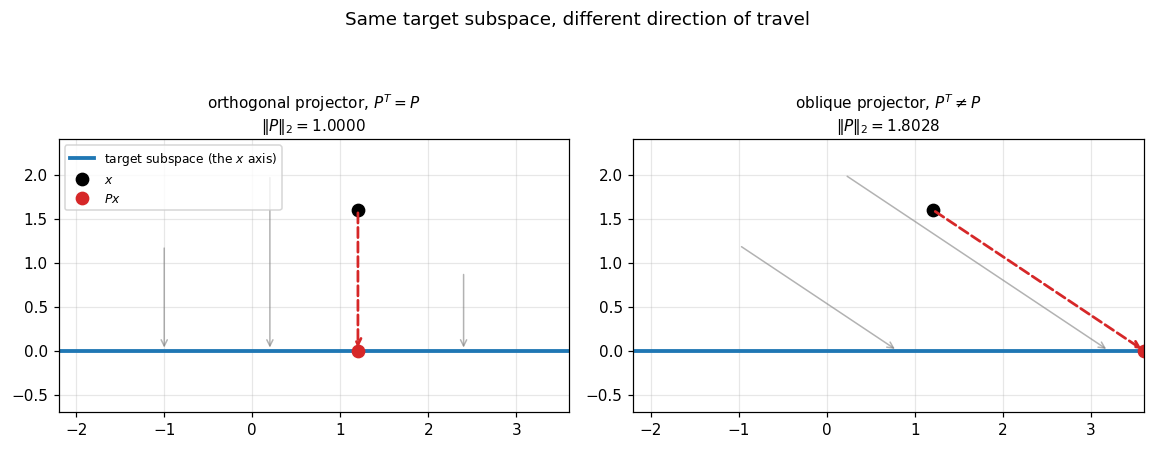

left  : the arrows drop STRAIGHT DOWN, perpendicular to the axis.
right : the arrows come in at a slant, so points move further than they
        need to. that extra distance is why ||P|| exceeds 1.


In [13]:
pt = np.array([1.2, 1.6])
fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.6))
for ax, M, name in [(axes[0], S, "orthogonal projector, $P^T = P$"),
                    (axes[1], T, "oblique projector, $P^T \\ne P$")]:
    img = M @ pt
    ax.axhline(0, color="C0", lw=2.5, label="target subspace (the $x$ axis)")
    ax.plot([pt[0]], [pt[1]], "ko", ms=8, label="$x$")
    ax.plot([img[0]], [img[1]], "C3o", ms=8, label="$Px$")
    ax.annotate("", xy=img, xytext=pt,
                arrowprops=dict(arrowstyle="->", lw=1.8, color="C3", ls="--"))
    for start in [np.array([-1.0, 1.2]), np.array([0.2, 2.0]), np.array([2.4, 0.9])]:
        ax.annotate("", xy=M @ start, xytext=start,
                    arrowprops=dict(arrowstyle="->", lw=1, color="gray", alpha=0.6))
    ax.set_xlim(-2.2, 3.6); ax.set_ylim(-0.7, 2.4)
    ax.set_aspect("equal")
    ax.set_title(f"{name}\n$\\|P\\|_2 = {la.matrix_norm(M,2):.4f}$", fontsize=10)
axes[0].legend(fontsize=8, loc="upper left")
plt.suptitle("Same target subspace, different direction of travel", y=0.99)
plt.tight_layout()
plt.show()

print("left  : the arrows drop STRAIGHT DOWN, perpendicular to the axis.")
print("right : the arrows come in at a slant, so points move further than they")
print("        need to. that extra distance is why ||P|| exceeds 1.")

## 5. Building orthogonal projectors from an orthonormal basis

> **Theorem 16.8.** Let $Q$ be $m \times n$ with orthonormal columns ($Q^TQ = I_n$). Then
> $$P = QQ^T$$
> is the orthogonal projector onto $\operatorname{range}(Q)$, and $\|P\|_2 = 1$ exactly
> (for $n \ge 1$).
>
> *Proof.* **Idempotent**: $P^2 = QQ^TQQ^T = Q(Q^TQ)Q^T = QI_nQ^T = QQ^T = P$.
> **Symmetric**: $P^T = (QQ^T)^T = QQ^T = P$.
> **Range**: $P\mathbf{x} = Q(Q^T\mathbf{x})$ is a combination of the columns of $Q$, so it
> lies in $\operatorname{range}(Q)$; and if $\mathbf{y} = Q\mathbf{c}$ is already there then
> $P\mathbf{y} = QQ^TQ\mathbf{c} = Q\mathbf{c} = \mathbf{y}$.
> **Norm**: for any $\mathbf{x}$, $\|P\mathbf{x}\|_2 = \|QQ^T\mathbf{x}\|_2 =
> \|Q^T\mathbf{x}\|_2 \le \|\mathbf{x}\|_2$ by Theorem 16.3 and the fact that $Q^T$ cannot
> increase length; and any $\mathbf{x}$ already in the range gives equality. $\square$

Notice the third bullet is Proposition 16.1 again: $Q^T\mathbf{x}$ are the coefficients, and
$Q$ times those coefficients rebuilds the piece of $\mathbf{x}$ that lives in the subspace.

In [14]:
rng5 = np.random.default_rng(5)
m, k = 8, 3
Qfull = og.random_orthogonal(m, rng5)
Qk = Qfull[:, :k]                       # an orthonormal basis for a 3-dimensional subspace
P = og.orthogonal_projector(Qk)

print(f"projecting R^{m} onto a {k}-dimensional subspace\n")
print(f"P^2 - P                : {np.abs(P @ P - P).max():.3e}")
print(f"P^T - P                : {np.abs(P - P.T).max():.3e}")
print(f"||P||_2                : {la.matrix_norm(P, 2):.12f}")
print(f"rank(P)                : {np.linalg.matrix_rank(P)}   (equals the subspace dimension)")
print(f"trace(P)               : {np.trace(P):.12f}   (a projector's trace IS its rank)")
print(f"eigenvalues of P       : {np.round(np.sort(np.linalg.eigvals(P).real)[::-1], 10)}")
print("\nevery eigenvalue is 0 or 1. that is forced by P^2 = P: if Pv = lv then")
print("l v = Pv = P^2 v = l^2 v, so l^2 = l, so l is 0 or 1.")
assert abs(np.trace(P) - k) < 1e-10
assert abs(la.matrix_norm(P, 2) - 1.0) < 1e-10

projecting R^8 onto a 3-dimensional subspace

P^2 - P                : 1.665e-16
P^T - P                : 0.000e+00
||P||_2                : 1.000000000000
rank(P)                : 3   (equals the subspace dimension)
trace(P)               : 3.000000000000   (a projector's trace IS its rank)
eigenvalues of P       : [ 1.  1.  1.  0.  0.  0. -0. -0.]

every eigenvalue is 0 or 1. that is forced by P^2 = P: if Pv = lv then
l v = Pv = P^2 v = l^2 v, so l^2 = l, so l is 0 or 1.


### Rank-one projectors: the building block

The simplest case is $k = 1$. For a unit vector $\mathbf{q}$,

$$P = \mathbf{q}\mathbf{q}^T \quad\text{projects onto the line through }\mathbf{q},
\qquad I - \mathbf{q}\mathbf{q}^T \quad\text{projects onto everything perpendicular to it.}$$

**Gram-Schmidt is nothing but repeated application of $I - \mathbf{q}\mathbf{q}^T$.** To make a
new vector orthogonal to the ones you already have, subtract off its component along each of
them, which is exactly applying these complementary projectors in turn. Lesson 30 develops
that.

In [15]:
q = la.normalize(np.array([1.0, 2.0, 2.0]))
Pq = og.rank_one_projector(q)
Pperp = og.complementary_projector(Pq)

print(f"q = {np.round(q, 6)},  ||q|| = {np.linalg.norm(q):.6f}\n")
print("P = q q^T =\n", np.round(Pq, 6))
print(f"\nrank {np.linalg.matrix_rank(Pq)}, trace {np.trace(Pq):.6f}, "
      f"||P||_2 {la.matrix_norm(Pq, 2):.6f}")
print(f"rank of I - P: {np.linalg.matrix_rank(Pperp)}, trace {np.trace(Pperp):.6f}")

z = np.array([4.0, 1.0, -2.0])
print(f"\nz          = {z}")
print(f"P z        = {np.round(Pq @ z, 6)}     (the part along q)")
print(f"(I - P) z  = {np.round(Pperp @ z, 6)}     (the part perpendicular to q)")
print(f"\nis (I-P)z perpendicular to q?  q.(I-P)z = {og.inner(q, Pperp @ z):.2e}")
print(f"do the pieces sum to z?        {np.abs(Pq @ z + Pperp @ z - z).max():.2e}")
assert abs(og.inner(q, Pperp @ z)) < 1e-14

q = [0.333333 0.666667 0.666667],  ||q|| = 1.000000

P = q q^T =
 [[0.111111 0.222222 0.222222]
 [0.222222 0.444444 0.444444]
 [0.222222 0.444444 0.444444]]

rank 1, trace 1.000000, ||P||_2 1.000000
rank of I - P: 2, trace 2.000000

z          = [ 4.  1. -2.]
P z        = [0.222222 0.444444 0.444444]     (the part along q)
(I - P) z  = [ 3.777778  0.555556 -2.444444]     (the part perpendicular to q)

is (I-P)z perpendicular to q?  q.(I-P)z = -4.44e-16
do the pieces sum to z?        0.00e+00


## 6. The projection residual is orthogonal to the subspace

This is the property that makes orthogonal projection the *right* answer rather than merely a
convenient one.

> **Theorem 16.9.** Let $P = QQ^T$ with $Q^TQ = I$, and let $\mathbf{r} = \mathbf{x} -
> P\mathbf{x}$. Then
>
> 1. $Q^T\mathbf{r} = \mathbf{0}$, so $\mathbf{r}$ is orthogonal to the whole subspace;
> 2. $\|\mathbf{x}\|_2^2 = \|P\mathbf{x}\|_2^2 + \|\mathbf{r}\|_2^2$ (Pythagoras);
> 3. $P\mathbf{x}$ is the **closest point** in the subspace to $\mathbf{x}$:
>    $\|\mathbf{x} - P\mathbf{x}\|_2 < \|\mathbf{x} - \mathbf{y}\|_2$ for every other
>    $\mathbf{y}$ in it.
>
> *Proof.* (1) $Q^T\mathbf{r} = Q^T\mathbf{x} - Q^TQQ^T\mathbf{x} = Q^T\mathbf{x} -
> Q^T\mathbf{x} = \mathbf{0}$.
> (2) $\mathbf{x} = P\mathbf{x} + \mathbf{r}$ with $(P\mathbf{x})^T\mathbf{r} =
> (Q^T\mathbf{x})^T(Q^T\mathbf{r}) = 0$ by (1), so the cross term in
> $\|P\mathbf{x} + \mathbf{r}\|^2$ vanishes.
> (3) Any $\mathbf{y}$ in the subspace gives $\mathbf{x} - \mathbf{y} = \mathbf{r} +
> (P\mathbf{x} - \mathbf{y})$, and the second piece is in the subspace so it is orthogonal to
> $\mathbf{r}$. Pythagoras again:
> $$\|\mathbf{x}-\mathbf{y}\|^2 = \|\mathbf{r}\|^2 + \|P\mathbf{x}-\mathbf{y}\|^2
> \ \ge\ \|\mathbf{r}\|^2,$$
> with equality only when $\mathbf{y} = P\mathbf{x}$. $\square$

**Part (3) is the least squares theorem.** Lesson 29 states it for a general basis, where the
condition $Q^T\mathbf{r} = 0$ becomes $A^T(\mathbf{b} - A\mathbf{x}) = 0$, the normal
equations. It is the same statement.

In [16]:
rng6 = np.random.default_rng(31)
m6, k6 = 10, 4
Q6 = og.random_orthogonal(m6, rng6)[:, :k6]
x6 = rng6.standard_normal(m6)

Px = Q6 @ (Q6.T @ x6)
r = og.projection_residual(x6, Q6)

print(f"residual orthogonal to every basis vector: max |q_j . r| = "
      f"{np.abs(Q6.T @ r).max():.3e}\n")
print(f"||x||^2          = {np.linalg.norm(x6)**2:.12f}")
print(f"||Px||^2 + ||r||^2 = {np.linalg.norm(Px)**2 + np.linalg.norm(r)**2:.12f}")
print(f"difference        = {abs(np.linalg.norm(x6)**2 - np.linalg.norm(Px)**2 - np.linalg.norm(r)**2):.2e}")

print(f"\nis Px really the closest point? distance from x:")
d_star = np.linalg.norm(x6 - Px)
print(f"   to Px                        : {d_star:.12f}")

others = np.array([np.linalg.norm(x6 - Q6 @ rng6.standard_normal(k6))
                   for _ in range(3000)])
print(f"   to 3000 other subspace points: min {others.min():.12f}, "
      f"max {others.max():.6f}")
print(f"\nevery one of the 3000 is further away, the closest by {others.min()-d_star:.3e}.")
print("theorem 16.9(3) says no point in the subspace can beat Px, and none does.")

assert np.abs(Q6.T @ r).max() < 1e-13
assert others.min() > d_star

residual orthogonal to every basis vector: max |q_j . r| = 8.916e-16

||x||^2          = 7.076904904542
||Px||^2 + ||r||^2 = 7.076904904542
difference        = 4.22e-15

is Px really the closest point? distance from x:
   to Px                        : 0.724484746607
   to 3000 other subspace points: min 0.861448033793, max 7.268339

every one of the 3000 is further away, the closest by 1.370e-01.
theorem 16.9(3) says no point in the subspace can beat Px, and none does.


## 7. How bad can an oblique projector be?

Orthogonal projectors always have norm exactly 1. Oblique ones have **no upper bound at all**,
and the blow-up has a precise formula.

> **Theorem 16.10.** Let $P$ be the oblique projector onto $\operatorname{range}(A)$ along the
> orthogonal complement of $\operatorname{range}(B)$, that is $P = A(B^TA)^{-1}B^T$. Then
> $$\|P\|_2 = \frac{1}{\cos\theta_{\max}},$$
> where $\theta_{\max}$ is the largest principal angle between the two subspaces. As the
> subspaces approach being orthogonal to each other, $\theta_{\max} \to \pi/2$ and
> $\|P\|_2 \to \infty$.

In [17]:
print("two 2-dimensional subspaces of R^3, closing on each other\n")
print(f"{'eps':>10} {'theta_max (deg)':>17} {'||P||_2':>14} {'1/cos(theta)':>15}")
print("-" * 60)
A7 = np.array([[1.0, 0.0], [0.0, 1.0], [0.0, 0.0]])
norms_P, angles = [], []
for eps in [1.0, 0.5, 0.2, 0.05, 0.01, 1e-3, 1e-5]:
    B7 = np.array([[1.0, 0.0], [0.0, eps], [0.0, np.sqrt(1 - eps**2)]])
    Pob = og.oblique_projector(A7, B7)
    th = og.largest_principal_angle(A7, B7)
    norms_P.append(la.matrix_norm(Pob, 2)); angles.append(th)
    print(f"{eps:>10.0e} {np.degrees(th):>17.6f} {la.matrix_norm(Pob,2):>14.4f} "
          f"{1/np.cos(th):>15.4f}")

print("\nthe last two columns agree exactly, which is the theorem.")
print("every one of these is a valid projector: P^2 = P holds in every row.")
print("the norm is unbounded anyway.")
np.testing.assert_allclose(norms_P, 1 / np.cos(angles), rtol=1e-8)
assert norms_P[-1] > 1e4

two 2-dimensional subspaces of R^3, closing on each other

       eps   theta_max (deg)        ||P||_2    1/cos(theta)
------------------------------------------------------------
     1e+00          0.000000         1.0000          1.0000
     5e-01         60.000000         2.0000          2.0000
     2e-01         78.463041         5.0000          5.0000
     5e-02         87.134016        20.0000         20.0000
     1e-02         89.427033       100.0000        100.0000
     1e-03         89.942704      1000.0000       1000.0000
     1e-05         89.999427    100000.0000     100000.0000

the last two columns agree exactly, which is the theorem.
every one of these is a valid projector: P^2 = P holds in every row.
the norm is unbounded anyway.


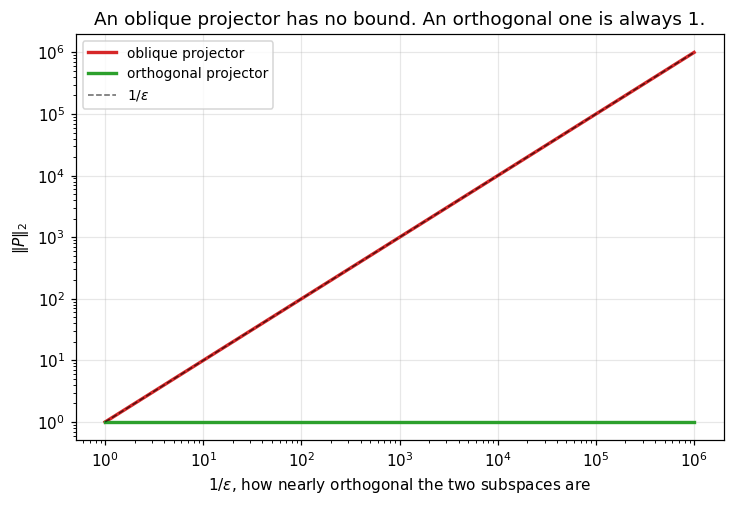

the green line is flat at exactly 1 across six orders of magnitude.
the red line rises without limit, and it is the same subspace being
projected onto in both cases. only the DIRECTION of projection differs.


In [18]:
eps_grid = np.logspace(0, -6, 60)
Pn, orth_line = [], []
for eps in eps_grid:
    B7 = np.array([[1.0, 0.0], [0.0, eps], [0.0, np.sqrt(1 - eps**2)]])
    Pn.append(la.matrix_norm(og.oblique_projector(A7, B7), 2))
    orth_line.append(la.matrix_norm(og.orthogonal_projector(np.linalg.qr(A7)[0]), 2))

fig, ax = plt.subplots(figsize=(7.6, 4.8))
ax.loglog(1 / eps_grid, Pn, "C3-", lw=2.2, label="oblique projector")
ax.loglog(1 / eps_grid, orth_line, "C2-", lw=2.2, label="orthogonal projector")
ax.loglog(1 / eps_grid, 1 / eps_grid, "k--", lw=1, alpha=0.6, label=r"$1/\epsilon$")
ax.set_xlabel(r"$1/\epsilon$, how nearly orthogonal the two subspaces are")
ax.set_ylabel(r"$\|P\|_2$")
ax.set_title("An oblique projector has no bound. An orthogonal one is always 1.")
ax.legend(fontsize=9, loc="upper left")
plt.show()

print("the green line is flat at exactly 1 across six orders of magnitude.")
print("the red line rises without limit, and it is the same subspace being")
print("projected onto in both cases. only the DIRECTION of projection differs.")

### Why this matters numerically

An error $\delta\mathbf{x}$ in the input becomes $P\delta\mathbf{x}$ in the output, so it is
amplified by up to $\|P\|_2$. With an orthogonal projector that factor is 1 and nothing can go
wrong. With an oblique one it is $1/\cos\theta_{\max}$, and at $\epsilon = 10^{-5}$ above that
is $10^5$: five digits gone, from a projection.

**Oblique projectors are not a curiosity to avoid.** Petrov-Galerkin methods project this way
on purpose, and GMRES (lesson 27) is one of them. Knowing that its projector can be badly
conditioned is precisely why its convergence theory is harder than the symmetric case.

In [19]:
print("the same input error, pushed through both projectors\n")
rng7 = np.random.default_rng(77)
eps = 1e-4
B8 = np.array([[1.0, 0.0], [0.0, eps], [0.0, np.sqrt(1 - eps**2)]])
P_ob = og.oblique_projector(A7, B8)
P_or = og.orthogonal_projector(np.linalg.qr(A7)[0])

worst_ob = worst_or = 0.0
for _ in range(2000):
    d = rng7.standard_normal(A7.shape[0])   # ambient dimension, from the data
    d = 1e-12 * d / np.linalg.norm(d)
    worst_ob = max(worst_ob, np.linalg.norm(P_ob @ d) / np.linalg.norm(d))
    worst_or = max(worst_or, np.linalg.norm(P_or @ d) / np.linalg.norm(d))

print(f"input error norm      : 1.0e-12")
print(f"worst amplification, orthogonal : {worst_or:>12.4f}")
print(f"worst amplification, oblique    : {worst_ob:>12.4f}")
print(f"\nso the same 1e-12 error comes out as at most "
      f"{1e-12*worst_or:.1e} through the orthogonal projector")
print(f"and up to {1e-12*worst_ob:.1e} through the oblique one.")
assert worst_or <= 1.0 + 1e-9
assert worst_ob > 100

the same input error, pushed through both projectors

input error norm      : 1.0e-12
worst amplification, orthogonal :       1.0000
worst amplification, oblique    :    9999.7809

so the same 1e-12 error comes out as at most 1.0e-12 through the orthogonal projector
and up to 1.0e-08 through the oblique one.


## 8. Complexity

| Operation | Cost | Note |
|---|---|---|
| $\mathbf{x}^T\mathbf{y}$ | $2n$ flops | |
| $Q^T\mathbf{x}$, coefficients in an orthonormal basis | $2mn$ flops | against $O(n^3)$ for a general basis |
| Apply $P = QQ^T$ **as written** | $O(m^2)$ per vector, $O(m^2n)$ to build | do not do this |
| Apply $P$ as `Q @ (Q.T @ x)` | $4mn$ flops, no matrix formed | do this |
| Householder reflector applied to a matrix | $O(mn)$ per column | never forms $H$ either |
| $\|P\|_2$, principal angles | $O(m n^2)$ | an SVD of $Q_A^TQ_B$ |

**Never form a projector explicitly.** $P = QQ^T$ is an $m \times m$ matrix built from an
$m \times n$ one, so for $m = 10^6$ and $n = 10$ it is a $10^{12}$-entry object standing in for
$10^7$ numbers. The same applies to Householder reflectors: lesson 31 applies them as
$\mathbf{x} - 2\mathbf{v}(\mathbf{v}^T\mathbf{x})/(\mathbf{v}^T\mathbf{v})$ and never builds
$H$.

In [20]:
import time

m9, n9 = 3000, 12
Q9 = np.linalg.qr(np.random.default_rng(9).standard_normal((m9, n9)))[0]
x9 = np.random.default_rng(10).standard_normal(m9)

t0 = time.perf_counter(); P9 = Q9 @ Q9.T; build = time.perf_counter() - t0
t0 = time.perf_counter()
for _ in range(50):
    a = P9 @ x9
t_dense = (time.perf_counter() - t0) / 50
t0 = time.perf_counter()
for _ in range(50):
    b = Q9 @ (Q9.T @ x9)
t_fact = (time.perf_counter() - t0) / 50

print(f"m = {m9}, subspace dimension n = {n9}\n")
print(f"P = Q Q^T is {P9.shape[0]} x {P9.shape[1]} = {P9.size:,} entries")
print(f"Q is        {Q9.shape[0]} x {Q9.shape[1]} = {Q9.size:,} entries, "
      f"a factor of {P9.size/Q9.size:,.0f} smaller\n")
print(f"time to build P        : {build*1e3:8.3f} ms")
print(f"apply as P @ x         : {t_dense*1e6:8.1f} us")
print(f"apply as Q @ (Q.T @ x) : {t_fact*1e6:8.1f} us    "
      f"({t_dense/t_fact:.1f}x faster)")
print(f"\nsame answer: {np.abs(a - b).max():.2e}")
np.testing.assert_allclose(a, b, atol=1e-12)

m = 3000, subspace dimension n = 12



P = Q Q^T is 3000 x 3000 = 9,000,000 entries
Q is        3000 x 12 = 36,000 entries, a factor of 250 smaller

time to build P        :   28.709 ms
apply as P @ x         :   2444.8 us
apply as Q @ (Q.T @ x) :     18.1 us    (134.9x faster)

same answer: 2.71e-16


## 9. Common mistakes

1. **Confusing an "orthogonal projector" with an "orthogonal matrix".** A projector onto a
   proper subspace is singular, so it cannot be an orthogonal matrix. Section 4.
2. **Forming $P = QQ^T$.** Section 8: for $m = 3000$, $n = 12$ that is 250 times more memory
   and slower to apply. Keep $Q$ and use it twice.
3. **Assuming any projector has $\|P\| = 1$.** Only the orthogonal ones. Section 7 measured an
   oblique one at $10^5$.
4. **Using the wrong sign in a Householder reflector.** Section 3: the cancelling choice makes
   $\|v\|$ collapse to roundoff when $\mathbf{x}$ is already near $\mathbf{e}_1$.
5. **Solving $Q\mathbf{c} = \mathbf{x}$ for orthonormal $Q$.** Section 1: the answer is
   $Q^T\mathbf{x}$, at $O(n^2)$ instead of $O(n^3)$, and it is more accurate.
6. **Believing $Q^TQ = I$ implies $QQ^T = I$.** True only for square $Q$. For a tall $Q$ with
   orthonormal columns, $QQ^T$ is the projector of section 5, not the identity.
7. **Forgetting to clip before `arccos`.** Roundoff can push a cosine to $1 + 10^{-16}$ and
   `arccos` returns `nan`. `nalib.orthogonality.angle_between` clips.

In [21]:
Qtall = og.random_orthogonal(6, np.random.default_rng(4))[:, :2]
print("mistake 6, checked directly. Q is 6 x 2 with orthonormal columns:\n")
rows, cols = Qtall.shape
print(f"||Q^T Q - I_{cols}||  = "
      f"{np.abs(Qtall.T @ Qtall - np.eye(cols)).max():.2e}   <- zero")
print(f"||Q Q^T - I_{rows}||  = "
      f"{np.abs(Qtall @ Qtall.T - np.eye(rows)).max():.4f}   <- NOT zero")
print(f"\nrank(Q Q^T) = {np.linalg.matrix_rank(Qtall @ Qtall.T)}, not 6. it is the")
print("projector onto the 2-dimensional column space, exactly as theorem 16.8 says.")
assert np.abs(Qtall @ Qtall.T - np.eye(rows)).max() > 0.5

mistake 6, checked directly. Q is 6 x 2 with orthonormal columns:

||Q^T Q - I_2||  = 3.33e-16   <- zero
||Q Q^T - I_6||  = 0.9644   <- NOT zero

rank(Q Q^T) = 2, not 6. it is the
projector onto the 2-dimensional column space, exactly as theorem 16.8 says.


## 10. Exercises

**Level 1, conceptual**

1.1 Why is $\kappa_2(Q) = 1$ the smallest a condition number can be? Prove no matrix has
$\kappa < 1$.

1.2 A projector has trace 7 and acts on $\mathbb{R}^{20}$. What is its rank, and what is the
rank of $I - P$?

1.3 Explain in one sentence why "$P$ is an orthogonal projector" and "$P$ is an orthogonal
matrix" cannot both be true unless $P = I$.

**Level 2, mathematical**

2.1 Prove that the eigenvalues of any projector are 0 and 1 only, and that the trace equals the
rank.

2.2 Prove that a projector is orthogonal (in the $P^T = P$ sense) **if and only if**
$\|P\|_2 \le 1$. One direction is Theorem 16.8; the other is the interesting one.

2.3 Prove that if $Q_1$ and $Q_2$ are orthogonal then so is $Q_1Q_2$, and that the orthogonal
matrices form a group under multiplication.

2.4 Derive the Householder reflector: given $\mathbf{x}$, find $\mathbf{v}$ such that
$(I - 2\mathbf{v}\mathbf{v}^T/\mathbf{v}^T\mathbf{v})\mathbf{x}$ is a multiple of
$\mathbf{e}_1$, and show both signs work mathematically.

2.5 Prove Theorem 16.10, that $\|P\|_2 = 1/\cos\theta_{\max}$ for the oblique projector. Use
the SVD of $Q_B^TQ_A$.

**Level 3, computational**

3.1 Implement `gram_schmidt(A)` returning an orthonormal basis for the column space, using
repeated application of $I - \mathbf{q}\mathbf{q}^T$. Measure $\|Q^TQ - I\|$ as a function of
$\kappa(A)$ and note what you find. Lesson 30 explains it.

3.2 Implement Householder QR for a general $m \times n$ matrix by applying reflectors to
successive columns, **never forming any $H$ explicitly**. Verify $\|A - QR\|/\|A\|$ and
$\|Q^TQ - I\|$ are both $O(u)$.

3.3 Write `is_orthogonal_matrix` with a tolerance that scales correctly with $n$. Determine
empirically how $\|Q^TQ - I\|$ grows with $n$ for matrices from `numpy.linalg.qr`, and choose
the tolerance to match.

**Level 4, experimental**

4.1 Generate 10000 random orthogonal matrices with `random_orthogonal` and confirm the
determinant is $\pm 1$ every time, with both signs roughly equally likely. Then remove the sign
correction from the function and show the distribution is no longer uniform.

4.2 For $n$ from 2 to 500, measure $\|Q^TQ - I\|_2$ for $Q$ from `numpy.linalg.qr` on a random
matrix. Fit the growth. Is it $O(u)$, $O(u\sqrt{n})$, or $O(un)$?

4.3 Take a subspace of $\mathbb{R}^{100}$ of dimension 50 and a nearby second subspace at
controlled principal angle. Plot $\|P_{\text{oblique}}\|_2$ against the angle across the full
range, and confirm the $1/\cos\theta$ law over as many decades as double precision allows.

**Level 5, advanced**

5.1 **The CS decomposition.** Any orthogonal matrix partitioned into blocks
$\begin{pmatrix}Q_{11} & Q_{12}\\ Q_{21} & Q_{22}\end{pmatrix}$ has all four blocks
simultaneously diagonalisable by orthogonal transformations, with the diagonal entries being
cosines and sines of the principal angles. State the theorem precisely, verify it numerically,
and use it to give a second proof of Theorem 16.10.

5.2 **Projections in non-Euclidean inner products.** For symmetric positive definite $M$, the
$M$-inner product is $\langle x,y\rangle_M = x^TMy$. Define $M$-orthogonal projection, derive
the projector, and show that it is oblique in the ordinary inner product but orthogonal in the
$M$ one. Conjugate gradient (lesson 24) is exactly this with $M = A$, which is why it minimises
the $A$-norm of the error rather than the residual.

5.3 **Why orthogonality is not free.** Orthogonal transformations do not amplify error, but the
process of *constructing* them can still be unstable. Investigate: build $Q$ by classical
Gram-Schmidt on an ill-conditioned matrix, measure $\|Q^TQ - I\|$, and then measure whether the
resulting nearly-orthogonal $Q$ still preserves norms. Distinguish carefully between "$Q$ is
orthogonal so it is safe to use" and "the algorithm that produced $Q$ was stable". Lesson 31
returns to this.

## 11. Key takeaways

- **The inner product defines everything here.** Length, angle and orthogonality are all
  statements about $\mathbf{x}^T\mathbf{y}$, and the 2-norm is the only $p$-norm that comes
  from one.
- **Expanding in an orthonormal basis costs a matrix-vector product, not a solve.** The
  coefficients are $Q^T\mathbf{x}$: $O(n^2)$ instead of $O(n^3)$, and stable.
- **$\|Q\mathbf{x}\|_2 = \|\mathbf{x}\|_2$, hence $\kappa_2(Q) = 1$.** Measured over 4000
  random directions in $\mathbb{R}^{60}$: the length change was zero to twelve decimal places
  in every direction.
- **An orthogonal transformation cannot amplify error.** Measured over 400 trials of 200 steps
  each: every orthogonal run ended with the error norm at exactly 1, while the general runs
  spanned a factor of $5 \times 10^5$, some growing and most shrinking. The general case is not
  reliably worse, it is reliably **unpredictable**, and that is what makes it unusable. **This
  is why QR, the SVD and the stable eigenvalue algorithms are all built from orthogonal
  operations.**
- **In the plane there are only rotations ($\det = +1$) and reflections ($\det = -1$).** The
  **Householder reflector** is the $n$-dimensional reflection that maps any $\mathbf{x}$ onto a
  multiple of $\mathbf{e}_1$. Its sign choice is a real stability fix: measured against a
  60-digit reference, the cancelling sign loses up to $5 \times 10^{-10}$ relative accuracy and
  divides by exactly zero when $\mathbf{x}$ is already on the axis, while the adding sign holds
  machine precision everywhere.
- **A projector is any $P$ with $P^2 = P$.** Its eigenvalues are 0 and 1 only, and its trace
  equals its rank. $I - P$ projects onto the complement, and $\mathbf{x}$ splits uniquely
  between them.
- **$P = QQ^T$ is the orthogonal projector onto $\operatorname{range}(Q)$**, with
  $\|P\|_2 = 1$ exactly. $P = \mathbf{q}\mathbf{q}^T$ is the rank-one case, and
  $I - \mathbf{q}\mathbf{q}^T$ is the step Gram-Schmidt repeats.
- **The residual is orthogonal to the subspace**, $Q^T(\mathbf{x} - P\mathbf{x}) = 0$, which
  gives Pythagoras and proves $P\mathbf{x}$ is the **closest** point. Verified against 3000
  competing points. **This is the least squares theorem**, and lesson 29 states it for a
  general basis.
- **Oblique projectors have no bound**: $\|P\|_2 = 1/\cos\theta_{\max}$, measured rising to
  $10^5$ while the orthogonal projector stayed at exactly 1 over six orders of magnitude. Same
  target subspace, different direction of travel.
- **Never form a projector.** Measured at $m = 3000$, $n = 12$: $P$ is 250 times more memory
  than $Q$ and applying it is slower.

## Where this goes next

Lesson 17 uses norms to analyse elimination, and lesson 18 shows what happens when the
transformations used are **not** orthogonal: the growth factor, and why pivoting is needed at
all. Part 4 projects onto Krylov subspaces, so Arnoldi (lesson 26) and Rayleigh-Ritz (lesson
39) are Theorem 16.9 applied repeatedly. Part 5 is this lesson made computational: lesson 29 is
Theorem 16.9(3) for a general basis, lesson 30 builds $Q$ by repeated $I - \mathbf{q}\mathbf{q}^T$,
and lesson 31 builds it from the Householder reflectors of section 3. Lesson 41 shows the SVD
is an orthogonal change of basis at both ends, which is why it is the most trustworthy
factorization there is.

Solutions are in [`solutions/part03_direct_linear_systems.md`](../solutions/part03_direct_linear_systems.md).